# Logistic Regression – Perceptron + Sigmoid View

Logistic Regression can be understood as a `Perceptron combined with a Sigmoid activation`.
This view helps explain how linear decision boundaries become probabilistic and differentiable.

---

## From Perceptron to Logistic Regression

### Perceptron Model

The perceptron computes:

$$
z = \theta^T x
$$

Prediction is made using a **hard threshold**:

$$
\hat{y} =
\begin{cases}
1 & \text{if } z \ge 0 \\
0 & \text{if } z < 0
\end{cases}
$$

This makes the perceptron:
- Non-probabilistic  
- Non-differentiable  
- Hard to optimize with gradient-based methods  

---

## Adding the Sigmoid Function

Logistic Regression replaces the hard threshold with a **sigmoid function**:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

where:

$$
z = \theta^T x
$$

The sigmoid maps any real value to a probability in the range $(0,1)$.

---

## Why the Sigmoid Is Important

The sigmoid function provides:
- Smooth output  
- Differentiability  
- Probabilistic interpretation  

This enables:
- Gradient descent optimization  
- Stable learning  
- Confidence-aware predictions  

---

## Decision Boundary

Even with the sigmoid, the **decision boundary remains linear**:

$$
\theta^T x = 0
$$

The sigmoid does **not change the boundary**, only how predictions are interpreted.

---

## Loss Function (Log Loss)

Logistic Regression minimizes **binary cross-entropy loss**:

$$
J(\theta) =
- \sum_{i=1}^{m}
\left[
y^{(i)} \log(\hat{y}^{(i)}) +
(1 - y^{(i)}) \log(1 - \hat{y}^{(i)})
\right]
$$

This loss heavily penalizes confident wrong predictions.

---

## Gradient Update (Perceptron Trick with Sigmoid)

The gradient of the loss leads to the update:

$$
\theta := \theta - \alpha (\hat{y} - y) x
$$

This resembles the perceptron update, but with key differences:
- Updates occur for **every data point**
- Update magnitude depends on **prediction error**
- Learning is smooth, not binary  

---

## Intuition

- Misclassified points produce large updates  
- Correctly classified points produce small or near-zero updates  
- The decision boundary moves gradually toward hard-to-classify points  

Thus, Logistic Regression behaves like a **soft perceptron**.

---

## Perceptron vs Logistic Regression

| Aspect | Perceptron | Logistic Regression |
|------|------------|---------------------|
| Activation | Step function | Sigmoid |
| Output | Hard class | Probability |
| Differentiable | No | Yes |
| Loss | Misclassification | Log loss |
| Optimization | Rule-based | Gradient descent |

---

## Key Takeaway

Logistic Regression = **Linear model + Sigmoid activation + Log loss**

The sigmoid transforms the perceptron into a probabilistic, differentiable model that can be
optimized efficiently using gradient descent, forming the foundation of neural networks.


In [1]:
%%capture
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

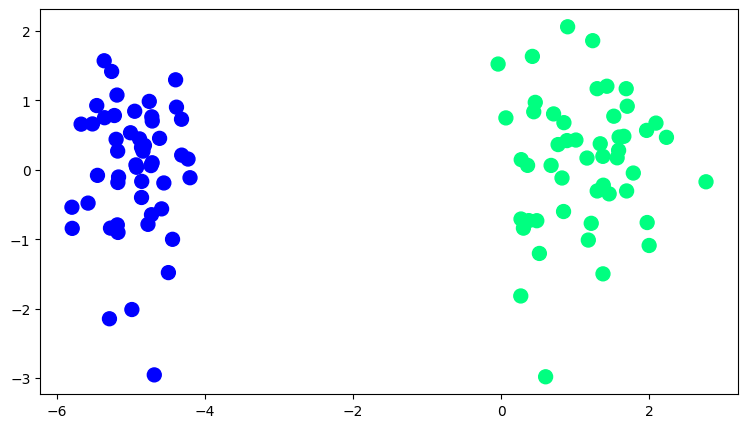

In [4]:
plt.figure(figsize=(9,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

### Perceptron Algorithm (Final Weights Only)

In [5]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]
        

In [6]:
def step(z):
    return 1 if z>0 else 0

In [7]:
intercept_,coef_ = perceptron(X,y)

In [8]:
print(coef_)
print(intercept_)

[1.1204053  0.40381514]
1.2000000000000002


In [9]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [10]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

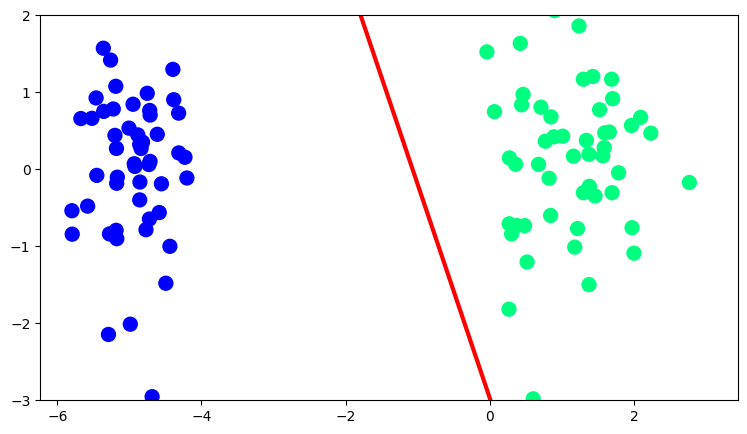

In [12]:
plt.figure(figsize=(9,5))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

### Scikit-Learn Built-in Logistic Regression Class

In [13]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [15]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

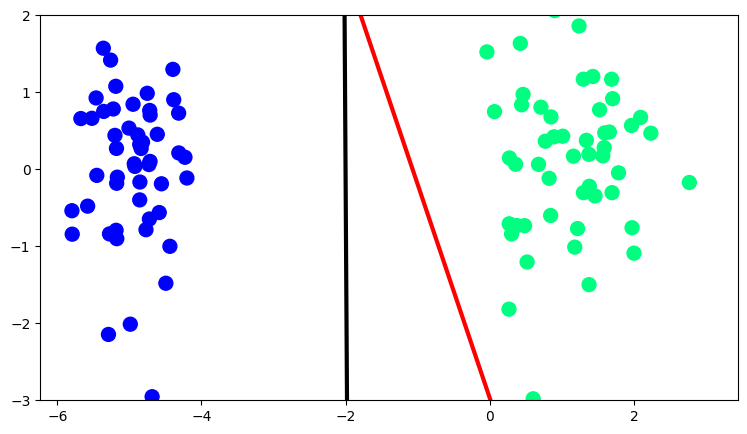

In [17]:
plt.figure(figsize=(9,5))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)


### Sigmoid Activation in Logistic Regression

In [18]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [19]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))


In [20]:
intercept_,coef_ = perceptron(X,y)

In [21]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [22]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

(-3.0, 2.0)

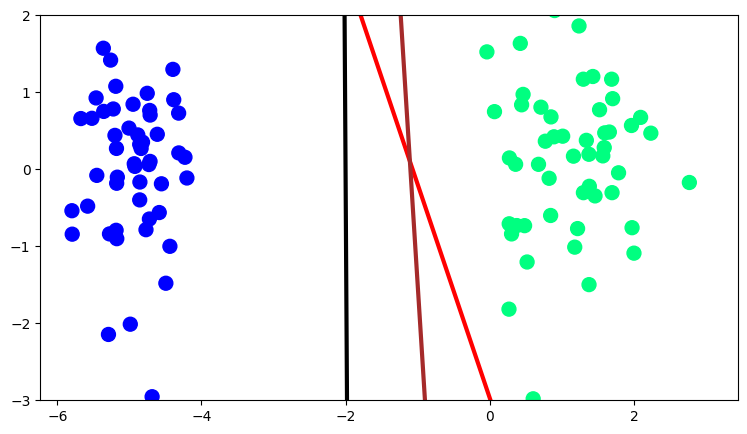

In [24]:
plt.figure(figsize=(9,5))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)